# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("citibike_station_day_clean.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["station_id", "date"]).reset_index(drop=True)

df.head()

,station_id,station_name,date,start_lat,start_lng,daily_trip_count,casual_share,member_share,classic_bike_share,electric_bike_share,mean_temperature,precipitation_sum,max_wind_speed,has_park,has_pier,has_ferry,has_plaza,has_square,has_station
0,3651.04,west drive & prospect park west,2026-01-02,40.661063,-73.979453,2,0.0,1.0,1.0,0.0,-4.4,0.3,14.4,1,0,0,0,0,0
1,3651.04,west drive & prospect park west,2026-01-03,40.661063,-73.979453,2,0.0,1.0,0.0,1.0,-3.5,0.0,10.3,1,0,0,0,0,0
2,3651.04,west drive & prospect park west,2026-01-04,40.661063,-73.979453,1,1.0,0.0,0.0,1.0,-2.2,0.3,12.1,1,0,0,0,0,0
3,3651.04,west drive & prospect park west,2026-01-05,40.661063,-73.979453,1,0.0,1.0,0.0,1.0,-1.8,0.8,12.6,1,0,0,0,0,0
4,3651.04,west drive & prospect park west,2026-01-06,40.661063,-73.979453,1,0.0,1.0,0.0,1.0,1.0,0.6,7.5,1,0,0,0,0,0


# 1. Clustering

## 1.1 Create Station-Level Features for Clustering

For clustering, we should not cluster every station-day row directly, because that would mostly separate days by weather and demand fluctuations. Instead, we aggregate to the station level and cluster stations based on their overall demand profile.

In [2]:
# Add basic calendar feature first
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

station_cluster_df = (
    df.groupby(["station_id", "station_name"])
    .agg(
        start_lat=("start_lat", "first"),
        start_lng=("start_lng", "first"),
        
        avg_daily_trips=("daily_trip_count", "mean"),
        median_daily_trips=("daily_trip_count", "median"),
        max_daily_trips=("daily_trip_count", "max"),
        sd_daily_trips=("daily_trip_count", "std"),
        
        avg_casual_share=("casual_share", "mean"),
        avg_member_share=("member_share", "mean"),
        avg_classic_bike_share=("classic_bike_share", "mean"),
        avg_electric_bike_share=("electric_bike_share", "mean"),
        
        has_park=("has_park", "max"),
        has_pier=("has_pier", "max"),
        has_plaza=("has_plaza", "max"),
        has_square=("has_square", "max"),
        
        n_days_observed=("date", "nunique")
    )
    .reset_index()
)

# Weekday and weekend average demand
weekday_avg = (
    df[df["is_weekend"] == 0]
    .groupby("station_id")["daily_trip_count"]
    .mean()
    .rename("weekday_avg_trips")
)

weekend_avg = (
    df[df["is_weekend"] == 1]
    .groupby("station_id")["daily_trip_count"]
    .mean()
    .rename("weekend_avg_trips")
)

station_cluster_df = station_cluster_df.merge(weekday_avg, on="station_id", how="left")
station_cluster_df = station_cluster_df.merge(weekend_avg, on="station_id", how="left")

# Derived station-level demand features
station_cluster_df["weekend_weekday_ratio"] = (
    station_cluster_df["weekend_avg_trips"] / station_cluster_df["weekday_avg_trips"]
)

station_cluster_df["cv_daily_trips"] = (
    station_cluster_df["sd_daily_trips"] / station_cluster_df["avg_daily_trips"]
)

station_cluster_df = station_cluster_df.replace([np.inf, -np.inf], np.nan).fillna(0)

station_cluster_df.head()

,station_id,station_name,start_lat,start_lng,avg_daily_trips,median_daily_trips,max_daily_trips,sd_daily_trips,avg_casual_share,avg_member_share,...,avg_electric_bike_share,has_park,has_pier,has_plaza,has_square,n_days_observed,weekday_avg_trips,weekend_avg_trips,weekend_weekday_ratio,cv_daily_trips
0,3651.04,west drive & prospect park west,40.661063,-73.979453,36.689655,34.0,113,30.633205,0.149350,0.850650,...,0.842574,1,0,0,0,57,39.700000,30.000000,0.755668,0.834928
1,3803.09,6 ave & 9 st,40.668127,-73.983776,36.472727,34.0,107,28.177253,0.068796,0.931204,...,0.777570,0,0,0,0,55,38.950000,29.866667,0.766795,0.772557
2,4051.01,berkeley pl & 7 ave,40.675147,-73.975232,49.793103,48.5,154,40.253041,0.039899,0.960101,...,0.758480,0,0,0,0,57,54.682927,38.000000,0.694915,0.808406
3,4125.07,7 ave & park pl,40.677615,-73.973243,41.810345,38.0,118,32.177936,0.083227,0.916773,...,0.766815,1,0,0,0,58,47.487805,28.117647,0.592102,0.769617
4,4157.10,bergen st & vanderbilt ave,40.679439,-73.968044,52.982143,51.5,137,40.066532,0.067958,0.932042,...,0.748892,0,0,0,0,56,55.525000,46.625000,0.839712,0.756227


In [3]:
#  avg_daily_trips           = overall station busyness
#  max_daily_trips           = peak demand
#  cv_daily_trips            = demand volatility
#  avg_casual_share          = tourist / leisure usage tendency
#  avg_electric_bike_share   = electric bike preference
#  weekend_weekday_ratio     = whether station is more leisure/weekend-oriented
#  location + POI flags      = spatial and neighborhood context

## 1.2 Scale features and choose number of clusters

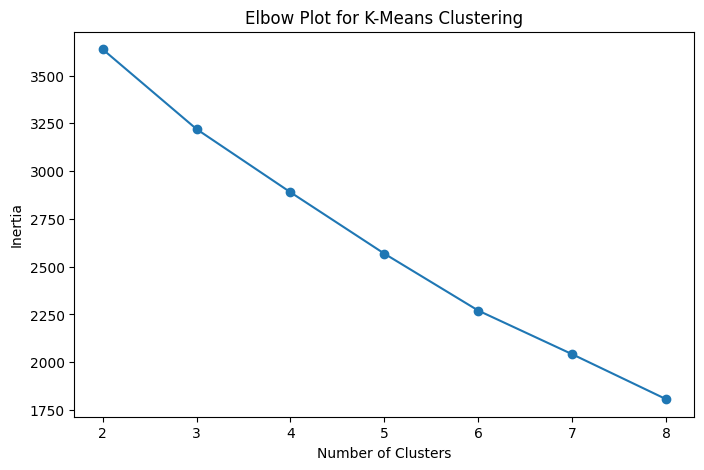

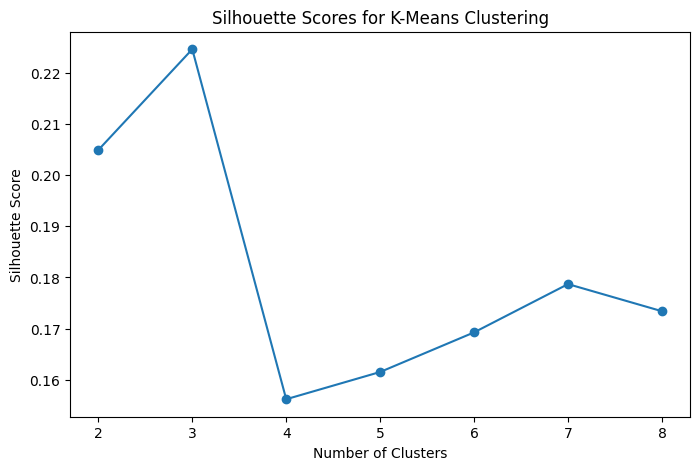

,k,inertia,silhouette_score
0,2,3637.667675,0.204889
1,3,3219.986727,0.224562
2,4,2889.349126,0.156229
3,5,2568.123362,0.161546
4,6,2270.245740,0.169282
5,7,2042.001319,0.178705
6,8,1806.786607,0.173408


In [4]:
cluster_features = [
    "start_lat",
    "start_lng",
    "avg_daily_trips",
    "median_daily_trips",
    "max_daily_trips",
    "cv_daily_trips",
    "avg_casual_share",
    "avg_member_share",
    "avg_electric_bike_share",
    "weekend_weekday_ratio",
    "has_park",
    "has_pier",
    "has_plaza",
    "has_square"
]

X_cluster = station_cluster_df[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

inertias = []
silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-Means Clustering")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means Clustering")
plt.show()

pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

## 1.3 Final K-Means Clustering

In [5]:
best_k = 4

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
station_cluster_df["station_cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

station_cluster_df["station_cluster"].value_counts().sort_index()

station_cluster
0     50
1    109
2    132
3      9
Name: count, dtype: int64

## 1.4 Cluster Summary

In [6]:
cluster_summary = (
    station_cluster_df
    .groupby("station_cluster")
    .agg(
        n_stations=("station_id", "count"),
        avg_daily_trips=("avg_daily_trips", "mean"),
        median_daily_trips=("median_daily_trips", "mean"),
        max_daily_trips=("max_daily_trips", "mean"),
        cv_daily_trips=("cv_daily_trips", "mean"),
        avg_casual_share=("avg_casual_share", "mean"),
        avg_member_share=("avg_member_share", "mean"),
        avg_electric_bike_share=("avg_electric_bike_share", "mean"),
        weekend_weekday_ratio=("weekend_weekday_ratio", "mean"),
        park_share=("has_park", "mean"),
        pier_share=("has_pier", "mean"),
        plaza_share=("has_plaza", "mean"),
        square_share=("has_square", "mean")
    )
    .round(3)
)

cluster_summary

,n_stations,avg_daily_trips,median_daily_trips,max_daily_trips,cv_daily_trips,avg_casual_share,avg_member_share,avg_electric_bike_share,weekend_weekday_ratio,park_share,pier_share,plaza_share,square_share
station_cluster,,,,,,,,,,,,,
0,50,82.712,74.220,257.680,0.802,0.073,0.927,0.711,0.608,0.020,0.02,0.000,0.02
1,109,49.217,39.849,167.266,0.868,0.071,0.929,0.731,0.511,0.046,0.00,0.000,0.00
2,132,45.055,41.773,130.795,0.765,0.073,0.927,0.702,0.761,0.023,0.00,0.000,0.00
3,9,48.226,41.111,168.111,0.816,0.192,0.808,0.754,0.559,0.889,0.00,0.111,0.00


## 1.5 PCA Visualization of Clusters

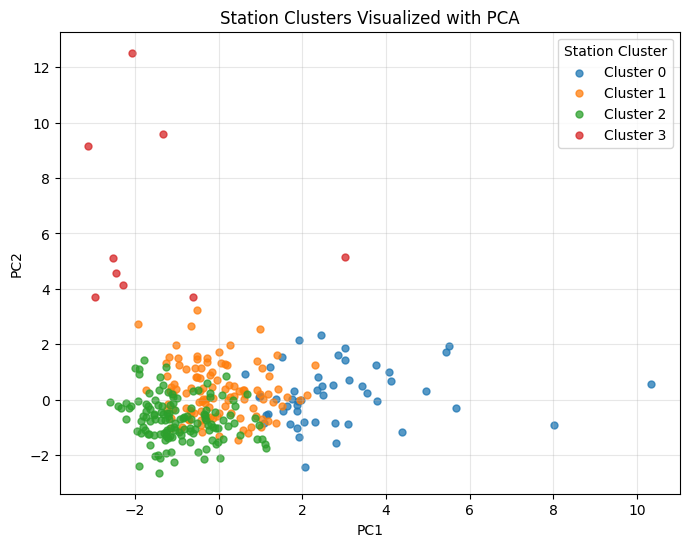

Explained variance ratio: [0.21229458 0.18117331]


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

station_cluster_df["PC1"] = X_pca[:, 0]
station_cluster_df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))

for cluster in sorted(station_cluster_df["station_cluster"].unique()):
    temp = station_cluster_df[station_cluster_df["station_cluster"] == cluster]
    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=25,              # smaller points
        alpha=0.75,
        label=f"Cluster {cluster}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Station Clusters Visualized with PCA")
plt.legend(title="Station Cluster")
plt.grid(alpha=0.3)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

## 1.6 Add Cluster Labels Back to Main Dataset

In [8]:
df = df.merge(
    station_cluster_df[["station_id", "station_cluster"]],
    on="station_id",
    how="left"
)

df.head()

,station_id,station_name,date,start_lat,start_lng,daily_trip_count,casual_share,member_share,classic_bike_share,electric_bike_share,...,max_wind_speed,has_park,has_pier,has_ferry,has_plaza,has_square,has_station,day_of_week,is_weekend,station_cluster
0,3651.04,west drive & prospect park west,2026-01-02,40.661063,-73.979453,2,0.0,1.0,1.0,0.0,...,14.4,1,0,0,0,0,0,4,0,3
1,3651.04,west drive & prospect park west,2026-01-03,40.661063,-73.979453,2,0.0,1.0,0.0,1.0,...,10.3,1,0,0,0,0,0,5,1,3
2,3651.04,west drive & prospect park west,2026-01-04,40.661063,-73.979453,1,1.0,0.0,0.0,1.0,...,12.1,1,0,0,0,0,0,6,1,3
3,3651.04,west drive & prospect park west,2026-01-05,40.661063,-73.979453,1,0.0,1.0,0.0,1.0,...,12.6,1,0,0,0,0,0,0,0,3
4,3651.04,west drive & prospect park west,2026-01-06,40.661063,-73.979453,1,0.0,1.0,0.0,1.0,...,7.5,1,0,0,0,0,0,1,0,3


# 2. Feature Engineering

## 2.1 Calendar Features

Day-of-week matters because the EDA shows weekday demand is higher than weekend demand. Cyclical encoding helps the model understand that Sunday and Monday are close in weekly time.

In [9]:
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding for day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

## 2.2 Weather Features

The scatterplot of demand vs precipitation suggests that high precipitation days often have lower demand. Instead of only using raw precipitation, binary indicators help capture bad-weather effects.

In [10]:
df["has_precipitation"] = (df["precipitation_sum"] > 0).astype(int)

df["heavy_precipitation"] = (
    df["precipitation_sum"] >= df["precipitation_sum"].quantile(0.90)
).astype(int)

df["high_wind"] = (
    df["max_wind_speed"] >= df["max_wind_speed"].quantile(0.90)
).astype(int)

## 2.3 Lag Demand Features

In [11]:
df = df.sort_values(["station_id", "date"]).reset_index(drop=True)

# Previous-day demand for the same station
df["lag_1_trip_count"] = (
    df.groupby("station_id")["daily_trip_count"]
    .shift(1)
)

# Same weekday last week demand for the same station
df["lag_7_trip_count"] = (
    df.groupby("station_id")["daily_trip_count"]
    .shift(7)
)

Recent demand is usually one of the strongest predictors of future Citi Bike demand. 
I created lag features based on each station’s previous demand history. The 1-day lag 
captures short-term demand persistence, while the 7-day lag captures weekly seasonality, 
since demand patterns may be similar on the same day of the week.

These lag features avoid directly using the current day's trip count as a predictor, so they 
provide useful historical information without target leakage.

## 2.4 Log Transform the Target Variable

In [12]:
df["log_daily_trip_count"] = np.log1p(df["daily_trip_count"])

The distribution of station-day demand is strongly right-skewed. Most station-day 
observations have relatively low or moderate trip counts, while a smaller number of 
station-days have very high demand. This pattern was also visible in the histogram and 
boxplot from the EDA.

To reduce the influence of extreme high-demand observations, I used a log transformation 
of the target variable. Specifically, I modeled log(1 + daily_trip_count), which keeps zero 
values valid while making the target distribution less skewed.

## 2.5 Remove Rows Without Lag Features

In [13]:
model_df = df.dropna(subset=["lag_1_trip_count", "lag_7_trip_count"]).copy()

model_df.shape

(14897, 32)

The lag features require previous observations for each station. Therefore, the earliest 
days for each station do not have valid lag values. I removed rows with missing lag features 
before model training because these rows do not contain enough historical information for 
the supervised learning task.

## 2.6 Define Candidate Modeling Features

In [14]:
numeric_features = [
    "start_lat",
    "start_lng",
    "mean_temperature",
    "precipitation_sum",
    "max_wind_speed",
    "has_precipitation",
    "heavy_precipitation",
    "high_wind",
    "lag_1_trip_count",
    "lag_7_trip_count",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "has_park",
    "has_pier",
    "has_plaza",
    "has_square"
]

categorical_features = [
    "station_cluster"
]

target = "log_daily_trip_count"

X = model_df[numeric_features + categorical_features]
y = model_df[target]

X.head()

,start_lat,start_lng,mean_temperature,precipitation_sum,max_wind_speed,has_precipitation,heavy_precipitation,high_wind,lag_1_trip_count,lag_7_trip_count,dow_sin,dow_cos,is_weekend,has_park,has_pier,has_plaza,has_square,station_cluster
7,40.661063,-73.979453,5.4,3.6,16.8,1,0,0,1.0,2.0,-0.433884,-0.900969,0,1,0,0,0,3
8,40.661063,-73.979453,6.0,13.5,14.6,1,1,0,2.0,2.0,-0.974928,-0.222521,1,1,0,0,0,3
9,40.661063,-73.979453,5.2,0.3,19.3,1,0,0,1.0,1.0,-0.781831,0.623490,1,1,0,0,0,3
10,40.661063,-73.979453,1.3,0.0,22.6,0,0,1,5.0,1.0,0.000000,1.000000,0,1,0,0,0,3
11,40.661063,-73.979453,2.7,0.0,15.5,0,0,0,3.0,1.0,0.781831,0.623490,0,1,0,0,0,3


The final modeling features include spatial information, weather conditions, calendar 
patterns, nearby location indicators, historical demand, and the station cluster label from 
the unsupervised learning step.

I did not include casual_share, member_share, classic_bike_share, or electric_bike_share in 
the main supervised model because these variables are calculated from trips that happen 
on the same day. If the goal is to predict demand ahead of time, these same-day trip 
composition variables may not be available before the day ends. Excluding them helps 
avoid target leakage and makes the prediction task more realistic.

## 2.7 Preprocessing Pipeline

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

The numeric variables were standardized so that variables measured on different scales, 
such as latitude, precipitation, wind speed, and lagged trip count, would be comparable 
during modeling. This is especially important for linear models such as Ridge Regression.

The station_cluster variable is categorical, so I used one-hot encoding to convert it into 
binary indicator variables. This allows supervised models to use the clustering result 
without incorrectly treating the cluster number as an ordered numeric value.

## 2.8 Featuring Summary

For feature engineering, I created several groups of predictors. First, I extracted calendar 
features from the date variable, including month, day of week, weekend indicators, and 
cyclical day-of-week features. These features capture weekly demand patterns, which are 
important because the EDA showed that weekday and weekend demand differ.

Second, I created weather-related indicators based on precipitation and wind speed. The 
EDA suggested that precipitation is associated with lower demand on some high-rainfall 
days, so I included both raw weather variables and binary severe-weather indicators.

Third, I created lagged demand features at the station level. The previous-day trip count 
captures short-term persistence, while the 7-day lag captures weekly seasonality. These 
features are useful because Citi Bike demand is likely related to recent station-specific 
usage patterns.

Finally, I merged the station cluster labels from the unsupervised learning step into the 
main dataset. These labels summarize station-level behavior and provide an additional 
high-level feature for supervised prediction. The target variable was log-transformed to 
reduce the effect of the strongly right-skewed demand distribution.

# 3. Supervised Machine Learning

The supervised learning task is to predict daily station-level Citi Bike demand. 
The target variable is log_daily_trip_count, which is the log-transformed version of daily_trip_count.

This is a regression problem because the response variable is numeric. 
The goal is to estimate how many trips a station will have on a given day using location, weather, calendar, station cluster, and historical demand features.

## 3.1 Time-based Train-Test Split

In [16]:
unique_dates = sorted(model_df["date"].unique())

split_index = int(len(unique_dates) * 0.8)

train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

train_mask = model_df["date"].isin(train_dates)
test_mask = model_df["date"].isin(test_dates)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Train dates:", min(train_dates), "to", max(train_dates))
print("Test dates:", min(test_dates), "to", max(test_dates))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train dates: 2026-01-08 00:00:00 to 2026-02-16 00:00:00
Test dates: 2026-02-17 00:00:00 to 2026-02-28 00:00:00
Train shape: (11638, 18)
Test shape: (3259, 18)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Model 1: Ridge Regression

In [18]:
ridge_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred_log = ridge_model.predict(X_test)

## Model 2: Random Forest Regression

In [19]:
rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred_log = rf_model.predict(X_test)

## Model 3: Gradient Boosting

In [20]:
gb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

gb_pred_log = gb_model.predict(X_test)

## Tuning Hyperparameter

In [21]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [3, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("Best CV RMSE:")
print(-rf_grid.best_score_)

best_rf_model = rf_grid.best_estimator_
best_rf_pred_log = best_rf_model.predict(X_test)

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}
Best CV RMSE:
0.3678861046408253


For supervised learning, I framed the project as a regression task predicting station-day Citi Bike demand. The target variable was the log-transformed daily trip count, which helps reduce the influence of the highly skewed demand distribution.

I trained three supervised models. Ridge Regression served as a simple baseline model and tested whether a mostly linear relationship was sufficient. Random Forest Regression was used to capture nonlinear relationships and interactions among weather, calendar, location, station cluster, and lagged demand features. Gradient Boosting Regression was included because it is often strong for structured tabular data and can learn complex patterns sequentially.

The models were trained using a time-based train-test split. Earlier dates were used for training, and later dates were held out for testing. This is more realistic than a random split because demand prediction is naturally a forecasting problem.

## Final Random Forest after tuning 

In [22]:
final_rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

final_rf_model.fit(X_train, y_train)

final_rf_pred_log = final_rf_model.predict(X_test)

# Model Evaluation

## 4.1 Evaluation Function

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model_name, y_true_log, y_pred_log):
    # Convert log-scale values back to original trip-count scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    # Avoid negative predicted trip counts
    y_pred = np.maximum(y_pred, 0)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 4.2 Model Comparison Table

In [24]:
results = []

results.append(evaluate_model("Ridge Regression", y_test, ridge_pred_log))
results.append(evaluate_model("Random Forest", y_test, rf_pred_log))
results.append(evaluate_model("Tuned Random Forest", y_test, final_rf_pred_log))
results.append(evaluate_model("Gradient Boosting", y_test, gb_pred_log))

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Tuned Random Forest,19.753143,28.130447,0.288724
1,Random Forest,21.228046,29.697965,0.207247
2,Gradient Boosting,24.703784,32.708560,0.038371
3,Ridge Regression,25.851368,35.782219,-0.150852


## 4.3 Predicted vs Actual Plot

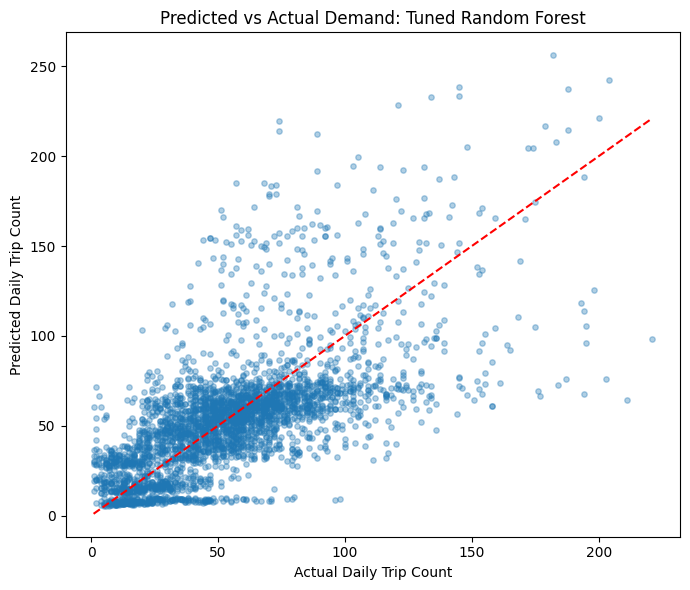

In [25]:
best_model_name = "Tuned Random Forest"
best_pred_log = final_rf_pred_log

y_test_original = np.expm1(y_test)
best_pred_original = np.expm1(best_pred_log)
best_pred_original = np.maximum(best_pred_original, 0)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_original, best_pred_original, alpha=0.35, s=15)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--", 
    color = "red"
)

plt.xlabel("Actual Daily Trip Count")
plt.ylabel("Predicted Daily Trip Count")
plt.title(f"Predicted vs Actual Demand: {best_model_name}")
plt.tight_layout()
plt.show()

## 4.4 Residual Plot

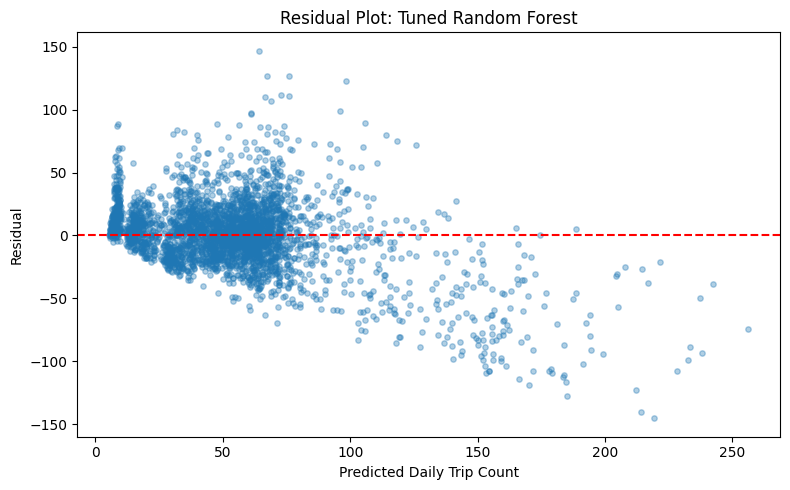

In [26]:
residuals = y_test_original - best_pred_original

plt.figure(figsize=(8, 5))
plt.scatter(best_pred_original, residuals, alpha=0.35, s=15)
plt.axhline(0, linestyle="--", color = "red")

plt.xlabel("Predicted Daily Trip Count")
plt.ylabel("Residual")
plt.title(f"Residual Plot: {best_model_name}")
plt.tight_layout()
plt.show()

## 4.5 Prediction Bias by Demand Level

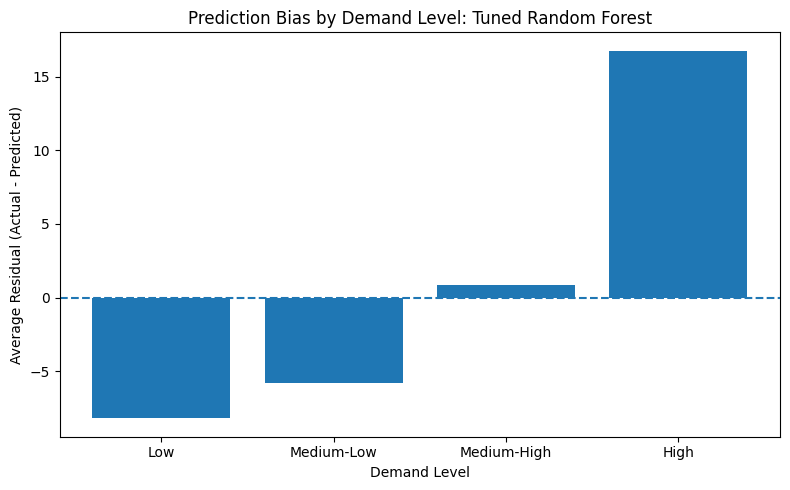

,demand_group,avg_actual,avg_predicted,avg_residual
0,Low,17.03,25.22,-8.19
1,Medium-Low,41.17,46.98,-5.81
2,Medium-High,61.48,60.65,0.83
3,High,99.90,83.14,16.76


In [27]:
# Use the final selected model
best_model_name = "Tuned Random Forest"
best_pred_log = final_rf_pred_log

# Convert back to original scale
y_test_original = np.expm1(y_test)
best_pred_original = np.expm1(best_pred_log)
best_pred_original = np.maximum(best_pred_original, 0)

# Build evaluation dataframe
bias_df = pd.DataFrame({
    "actual": y_test_original,
    "predicted": best_pred_original
})

# Residual = actual - predicted
# Positive residual  -> model predicted too low
# Negative residual  -> model predicted too high
bias_df["residual"] = bias_df["actual"] - bias_df["predicted"]

# Group observations by actual demand level
bias_df["demand_group"] = pd.qcut(
    bias_df["actual"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

bias_summary = (
    bias_df.groupby("demand_group")
    .agg(
        avg_actual=("actual", "mean"),
        avg_predicted=("predicted", "mean"),
        avg_residual=("residual", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.bar(bias_summary["demand_group"], bias_summary["avg_residual"])
plt.axhline(0, linestyle="--")

plt.xlabel("Demand Level")
plt.ylabel("Average Residual (Actual - Predicted)")
plt.title(f"Prediction Bias by Demand Level: {best_model_name}")
plt.tight_layout()
plt.show()

bias_summary.round(2)

To better understand model behavior, I plotted the average residual by demand level. 
Residuals are defined as actual minus predicted demand. Positive values indicate underprediction, while negative values indicate overprediction. 

This figure provides a simple visual summary of whether the model tends to overestimate or underestimate demand at different parts of the demand distribution.

## 4.6 Error by Demand Level

In [28]:
eval_df = pd.DataFrame({
    "actual": y_test_original,
    "predicted": best_pred_original
})

eval_df["absolute_error"] = np.abs(eval_df["actual"] - eval_df["predicted"])

eval_df["demand_group"] = pd.qcut(
    eval_df["actual"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

error_by_group = (
    eval_df
    .groupby("demand_group")
    .agg(
        n=("actual", "count"),
        avg_actual=("actual", "mean"),
        avg_predicted=("predicted", "mean"),
        mae=("absolute_error", "mean")
    )
    .round(2)
)

error_by_group

,n,avg_actual,avg_predicted,mae
demand_group,,,,
Low,815,17.03,25.22,14.28
Medium-Low,855,41.17,46.98,16.64
Medium-High,801,61.48,60.65,15.98
High,788,99.90,83.14,32.62


## 4.7 Actual vs Predicted Distribution

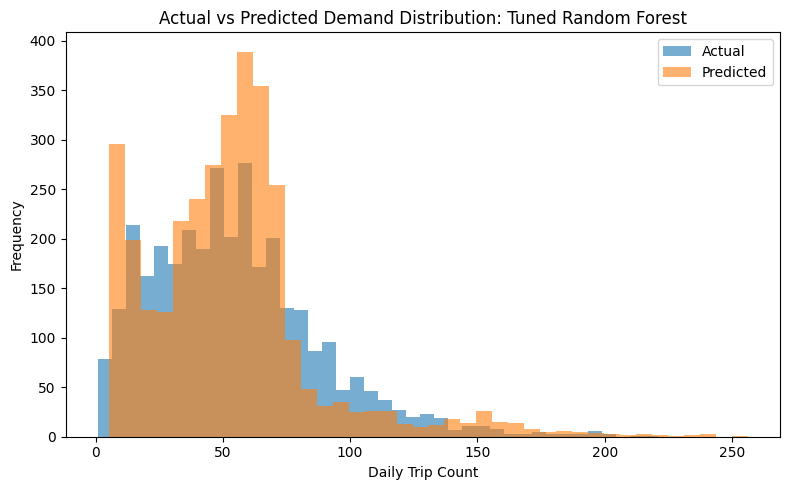

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(y_test_original, bins=40, alpha=0.6, label="Actual")
plt.hist(best_pred_original, bins=40, alpha=0.6, label="Predicted")

plt.xlabel("Daily Trip Count")
plt.ylabel("Frequency")
plt.title(f"Actual vs Predicted Demand Distribution: {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 4.8 Feature Importance for Tuned Random Forest

In [30]:
# Extract one-hot encoded categorical feature names
ohe = final_rf_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_feature_names)

importances = final_rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
8,lag_1_trip_count,0.505572
2,mean_temperature,0.193591
4,max_wind_speed,0.075081
3,precipitation_sum,0.061402
9,lag_7_trip_count,0.056022
10,dow_sin,0.020108
0,start_lat,0.019445
1,start_lng,0.017516
6,heavy_precipitation,0.017033
17,station_cluster_0,0.010944


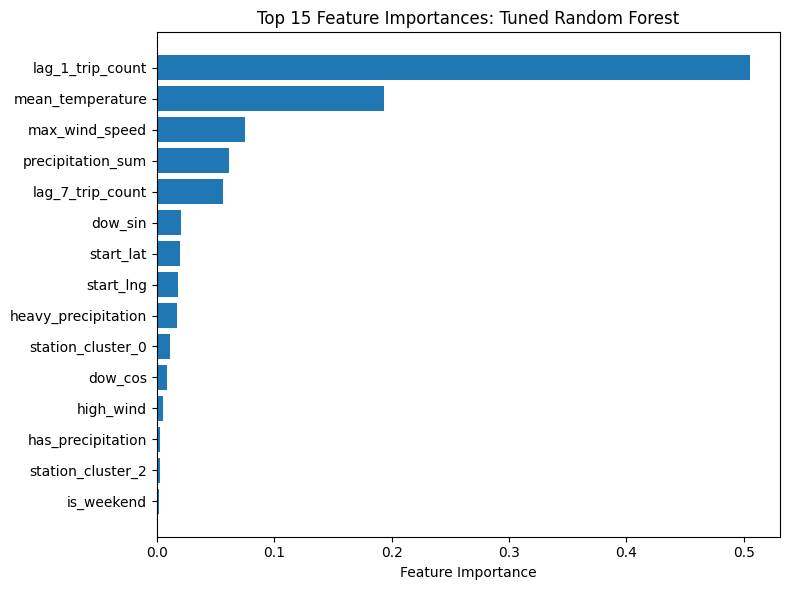

In [31]:
top_importance = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances: Tuned Random Forest")
plt.tight_layout()
plt.show()